# Portfolio Project: Life Expectancy and GDP Analysis

## Project Overview
This project explores the relationship between Gross Domestic Product (GDP) and life expectancy at birth across six nations: **Chile, China, Germany, Mexico, United States of America, and Zimbabwe**. The dataset is sourced from the World Health Organization (WHO) and the World Bank, spanning the years 2000 through 2015.

---

## 1. Project Goals
The primary objective is to investigate whether economic output directly correlates with higher life expectancy, and how that relationship manifests differently across distinct economic structures.

### Key Questions to Answer:
* **Trend Analysis:** Has life expectancy increased over time in each of the six nations?
* **Economic Trajectory:** Has GDP grown over time in each of the six nations?
* **Correlation:** Is there a strong statistical correlation between a nation's GDP and its life expectancy?
* **Comparative Distribution:** What is the average life expectancy for each nation, and how do distributions compare between high-GDP and low-GDP countries?

---

## 2. Dataset Overview
* **Source File:** `all_data.csv`
* **Features:**
  * `Country`: Categorical variable identifying the nation.
  * `Year`: Temporal variable ranging from 2000 to 2015.
  * `Life expectancy at birth (years)`: Continuous numerical target metric.
  * `GDP`: Continuous numerical economic output in USD.

---

## 3. Analytical Strategy
1. **Data Wrangling:** Load data, inspect for missing values, and standardize column names (e.g., rename `Life expectancy at birth (years)` to `LEABY`).
2. **Univariate Analysis:** Examine individual variable distributions using summary statistics, histograms, and bar charts.
3. **Bivariate & Time-Series Analysis:** Plot line charts to trace GDP and life expectancy trajectories over time per country.
4. **Correlation Analysis:** Construct scatter plots with regression trendlines overall and faceted by country to isolate nation-specific relationships.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('all_data.csv')

# Inspect first few rows
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


## Step 1: Data Cleaning & Column Standardization
Rename the long column name `Life expectancy at birth (years)` to `LEABY` to simply future function calls and data plotting.

In [3]:
# Rename long column name for easier reference
df.rename(columns={"Life expectancy at birth (years)": "LEABY"}, inplace=True)

# Inspect summary statistics and data structure
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  96 non-null     object 
 1   Year     96 non-null     int64  
 2   LEABY    96 non-null     float64
 3   GDP      96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB
None
              Year      LEABY           GDP
count    96.000000  96.000000  9.600000e+01
mean   2007.500000  72.789583  3.880499e+12
std       4.633971  10.672882  5.197561e+12
min    2000.000000  44.300000  4.415703e+09
25%    2003.750000  74.475000  1.733018e+11
50%    2007.500000  76.750000  1.280220e+12
75%    2011.250000  78.900000  4.067510e+12
max    2015.000000  81.000000  1.810000e+13


### Key Takeaways:
* **Complete Dataset with No Missing Values:** There are exactly **96 entries** (rows) across 4 columns (`Country`, `Year`, `LEABY`, and `GDP`), with 96 non-null counts in every field. No data cleaning or imputation for missing values is required.
* **Granular Timeframe & Balanced Sample:** The dataset contains 16 consecutive years of data per country (from **2000 to 2015**), representing 6 distinct nations (6 x 16 = 96).
* **Wide Variance in Life Expectancy:** Across all observations, life expectancy ranges from a minimum of **44.3 years** to a maximum of **81.0 years**, with an overall average of **72.8 years**.
* **Significant Scale Disparities in GDP:** GDP spans from a minimum of **4.42 billion** (e.g., lower-income nations like Zimbabwe in earlier years) to a maximum of **18.1 trillion** (high-income nation like the US).

## Step 2: Distribution & Summary Visualizations
Analyze the overall distributions and average across 

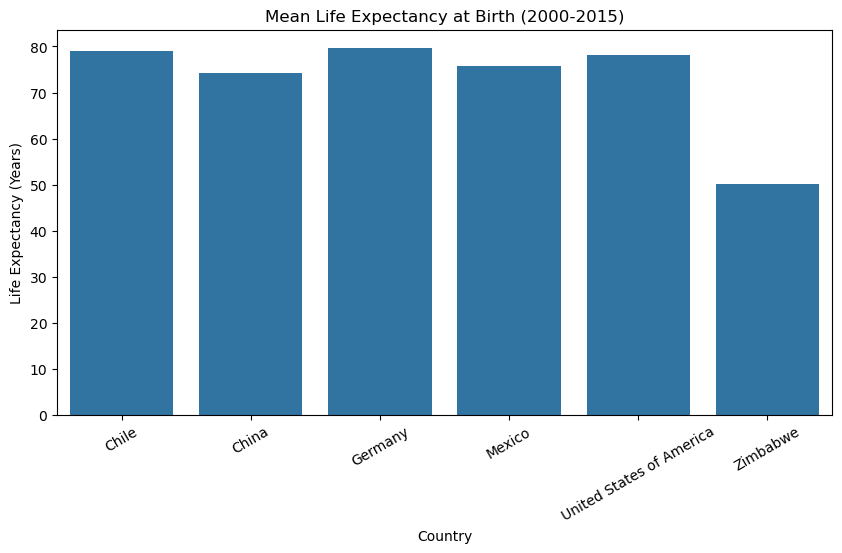

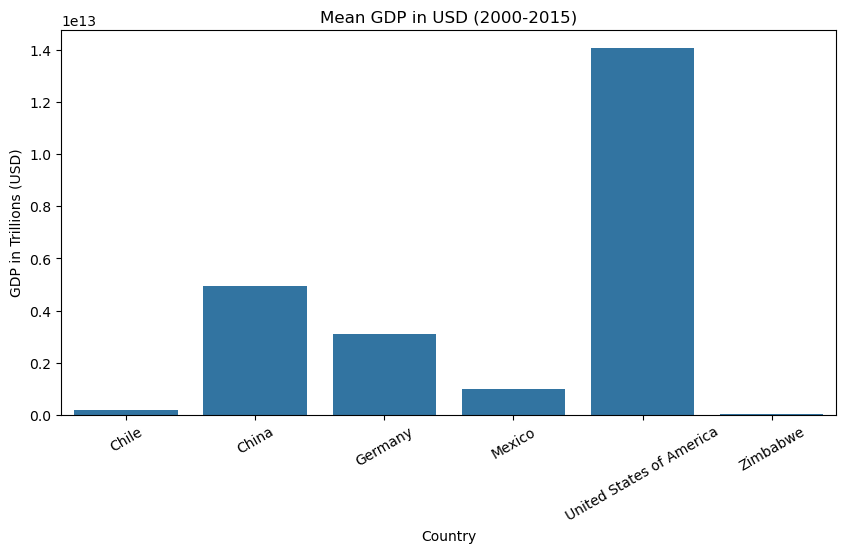

In [7]:
# Average Life Expectancy and GDP by Country
df_means = df.groupby("Country")[["LEABY", "GDP"]].mean().reset_index()

# Plot Average Life Expectancy
plt.figure(figsize=(10, 5))
sns.barplot(data=df_means, x="Country", y="LEABY")
plt.title("Mean Life Expectancy at Birth (2000-2015)")
plt.ylabel("Life Expectancy (Years)")
plt.xticks(rotation=30)
plt.savefig('average_life_expectancy.png', bbox_inches='tight')
plt.show()

# Plot Average GDP
plt.figure(figsize=(10, 5))
sns.barplot(data=df_means, x="Country", y="GDP")
plt.title("Mean GDP in USD (2000-2015)")
plt.ylabel("GDP in Trillions (USD)")
plt.xticks(rotation=30)
plt.savefig('average_GDP.png', bbox_inches='tight')
plt.show()

### Key Takeaways:
* **High Baseline for Most Nations:** Five out of the six nations (Chile, China, Germany, Mexico, and the United States) have average life expectancies clustered tightly between **74 and 80 years**.
* **Zimbabwe is a Significant Outlier:** Zimbabwe's average life expectancy is drastically lower at approximately **50 years**, reflecting severe public health and socioeconomic challenges during the 2000-2015 timeframe.
* **Disproportionate GDP Distribution:** When comparing economic output across the nations, the United States and China dominate total average GDP, with the US averaging near **14 trillion** and China around **4.9 trillion**, while Chile, Mexico, Germany, and Zimbabwe sit at significantly lower absolute levels.
* **Non-Linear Relationship at First Glance:** High life expectancy is not exclusively restricted to high-GDP nations; for instance, Chile maintains an average life expectancy comparable to or slightly exceeding that of the US despite having a much smaller overall GDP.

## Step 4: Isolate GDP vs. Life Expectancy Correlation
Faceting by country avoids visual distortion caused by large differences in GDP scale between nations (e.g. Zimbabwe vs. United States).

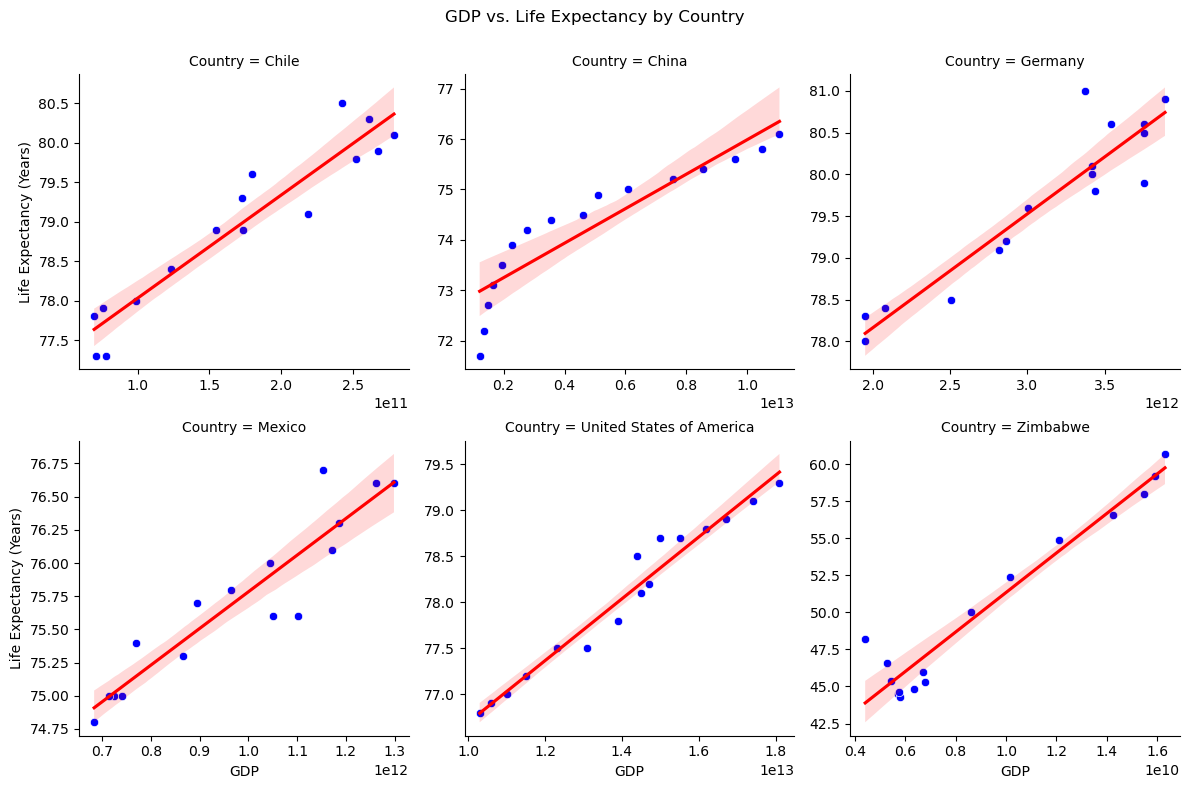

In [8]:
# Faceted Scatter Plots to isolate country-specific relationships
g = sns.FacetGrid(df, col="Country", col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.scatterplot, "GDP", "LEABY", color="b")
g.map(sns.regplot, "GDP", "LEABY", scatter=False, color="r")
g.set_axis_labels("GDP", "Life Expectancy (Years)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("GDP vs. Life Expectancy by Country")
plt.savefig('gdp_life_expectancy_by_country.png', bbox_inches='tight')
plt.show()

## Key Takeaways:
* **Universal Positive Correlation Across All Nations:** Every single country exhibits a strong positive relationship between GDP growth and life expectancy. As GDP increases, life expectancy consistently rises in all six nations.
* **Zimbabwe's Rapid Gains:** Zimbabwe shows the steepest positive linear slope in the dataset. Starting from around 45 years at low GDP levels, life expectancy climbed rapidly to over 60 years as its GDP increased toward 1.6e10 (\\$16 billion), demonstrating massive relative public health returns on economic growth.
* **Diminishing Returns in High-GDP Nations:** Highly developed economies like the United States and Germany show much flatter regression slopes. For instance, in the US, an increase in GDP from ~\\$10 trillion to ~\\$18 trillion corresponds to a smaller, incremental gain in life expectancy (from ~77.5 to ~79.3 years), illustrating that once basic health infrastructure is established, marginal gains require significantly greater economic investment.
* **Country-Specific Clusters & Variations:**
  * **China & Chile:** Both display tight, steady linear upward trends, showing strong consistency between national economic growth and life expectancy gains.
  * **Mexico:** Exhibits a general positive trajectory, though with greater variance/scatter around the trendline compared to Chile or China.

# Project Conclusions & Takeaways

## 1. Personal Learnings
Throughout this analysis, I learned that economic magnitude does not strictly dictate individual life expectancy. While the United States possesses a vast total GDP compared to many other nations in the dataset, several nations achieve nearly equal life expectancy outcomes. This underscores that factors beyond aggregate gross economic output - such as public health allocation, healthcare accessibility, and baseline social infrastructure - play critical roles in determining population longevity.

## 2. Surprising Findings
* **Parity Among Diverse Economies:** I was surprised to find that countries like **Chile, Mexico, and China** maintain life expectancies nearly equal to those of leading global economies like the **United States and Germany** (clustered between 74 and 80 years), despite operating at vastly different absolute GDP scales.
* **The Zimbabwe Outlier:** I was also struck by the vast disparity between **Zimbabwe** and all other countries in the dataset. Zimbabwe's average life expectancy hovered around 50 years during this period, reflecting the profound impact of localized socioeconomic and public health crises relative to higher-income nations.

## 3. Key Findings & Core Takeaways
1. **Universal Positive Correlation:** Every nation in the study exhibited a positive relationship between GDP growth and life expectancy gains. As a country's economic output expanded from 2000 to 2015, its population's life expectancy consistently increased.
2. **Step Public Health Returns in Developing Nations:** Low-GDP nations like Zimbabwe experienced the steepest upward gains in life expectancy as GDP drew, demonstrating that early-stage economic growth yields massive public health returns.
3. **Diminishing Marginal Returns in Developed Nations:** High-GDP nations like the United States and Germany displayed flatter regression slopes. Once basic infrastructure and healthcare systems are established, multi-trillion-dollar increases in GDP result in smaller, incremental improvements in life expectancy.

## Published Article & Summary

Read the full write-up and data visualization story on Medium:

[Beyond the Trillions: What GDP Can (and Can't) Tell Us About Global Life Expectancy](https://medium.com/@longm7718/diminishing-returns-health-disparities-a-data-visualization-study-of-global-gdp-and-life-e16fd45387f9)